 # Deep Learning - Assignment 3
 ## Lyrics Generation using RNNs

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

In [107]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi
import os
import re
import random
from tqdm import tqdm
import gensim.downloader as api
import mido

In [108]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 1. Data Loading and Preprocessing

In [109]:
# Load lyrics data
def load_lyrics_data(file_path):
    """Load lyrics data from CSV file."""
    df = pd.read_csv(file_path, header=None, usecols=[0, 1, 2])
    df.columns = ['artist', 'song', 'lyrics']
    return df


train_lyrics = load_lyrics_data('data/lyrics_train_set.csv')
test_lyrics = load_lyrics_data('data/lyrics_test_set.csv')

# Display sample of the data
print("Training data shape:", train_lyrics.shape)
print("Test data shape:", test_lyrics.shape)

Training data shape: (600, 3)
Test data shape: (5, 3)


In [110]:
# Function to load and extract features from MIDI files
def load_midi_features(midi_file_path):
    """Extract features from a MIDI file using pretty_midi."""
    midi_data = pretty_midi.PrettyMIDI(midi_file_path)

    # Basic MIDI features
    features = {}

    # Tempo information
    tempo_changes = midi_data.get_tempo_changes()
    if tempo_changes[1].size > 0:
        features['tempo'] = np.mean(tempo_changes[1])
    else:
        features['tempo'] = 120.0  # Default tempo if none found

    # Extract note features from the first instrument (assuming melody)
    notes = []

    for inst in midi_data.instruments:
        for note in inst.notes:
            notes.append({
                'pitch': note.pitch,
                'start': note.start,
                'end': note.end,
                'duration': note.end - note.start,
                'velocity': note.velocity
            })
        # Convert to numpy arrays for easier manipulation
        if notes:
            pitches = np.array([note['pitch'] for note in notes])
            durations = np.array([note['duration'] for note in notes])
            velocities = np.array([note['velocity'] for note in notes])
            features['avg_pitch'] = np.mean(pitches)
            features['pitch_std'] = np.std(pitches)
            features['pitch_range'] = np.max(pitches) - np.min(pitches)
            features['avg_duration'] = np.mean(durations)
            features['avg_velocity'] = np.mean(velocities)
            features['note_density'] = len(notes) / midi_data.get_end_time()
            # Store the sequence of notes (for detailed melody representation)
            features['note_sequence'] = [
                {'pitch': note.pitch,
                 'start': note.start,
                 'duration': note.end - note.start,
                 'velocity': note.velocity}
                for note in inst.notes
            ]

    return features

In [111]:
# Test MIDI feature extraction on a sample file
midi_files_dir = 'data/midi_files'
sample_midi_file = os.path.join(midi_files_dir, os.listdir(midi_files_dir)[0])
print(f"Testing feature extraction on: {sample_midi_file}")
sample_features = load_midi_features(sample_midi_file)

for key, value in sample_features.items():
    if key != 'note_sequence':
        print(f"{key}: {value}")
print(f"Number of notes in sequence: {len(sample_features['note_sequence'])}")

Testing feature extraction on: data/midi_files\1910_Fruitgum_Company_-_Simon_Says.mid
tempo: 135.000135000135
avg_pitch: 60.3775082359988
pitch_std: 14.32627598325973
pitch_range: 62
avg_duration: 0.23320713371331242
avg_velocity: 119.95941898772088
note_density: 42.14915457519008
Number of notes in sequence: 78


## 2. Data Preprocessing

In [112]:
# Process lyrics into tokenized format
def preprocess_lyrics(lyrics_series):
    """Preprocess and tokenize lyrics."""
    all_lyrics = []
    for lyric in lyrics_series:
        # Convert to lowercase and split into lines
        lyric = str(lyric).lower()
        lines = lyric.split('&')

        # Process each line
        for line in lines:
            # Clean and tokenize
            tokens = re.findall(r'\b\w+\b', line)
            if tokens:  # Skip empty lines
                all_lyrics.append(tokens)

    return all_lyrics


# Process train and test lyrics
train_tokenized = preprocess_lyrics(train_lyrics.iloc[:, 2])
test_tokenized = preprocess_lyrics(test_lyrics.iloc[:, 2])

print(f"Number of lines in training set: {len(train_tokenized)}")
print(f"Number of lines in test set: {len(test_tokenized)}")

Number of lines in training set: 23860
Number of lines in test set: 189


In [113]:
# Build vocabulary
def build_vocabulary(tokenized_lyrics, min_freq=2):
    """Build vocabulary from tokenized lyrics."""
    word_counts = Counter()
    for line in tokenized_lyrics:
        word_counts.update(line)

    vocab = {'<PAD>': 0, '<UNK>': 1, '<START>': 2, '<END>': 3}
    idx = 4

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab, word_counts


vocab, word_counts = build_vocabulary(train_tokenized)
print(f"Vocabulary size: {len(vocab)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Vocabulary size: 4033
Top 10 most common words: [('i', 7259), ('you', 6902), ('the', 5846), ('to', 3776), ('and', 3701), ('a', 3094), ('it', 2995), ('me', 2830), ('s', 2385), ('my', 2177)]


In [114]:
# Load Word2Vec embedding
print("Loading Word2Vec embeddings...")
word2vec_model = api.load('word2vec-google-news-300')
print("Word2Vec model loaded with vector size:", word2vec_model.vector_size)


# Create embedding matrix for our vocabulary
def create_embedding_matrix(vocab, embedding_model, embedding_dim=300):
    """Create embedding matrix for words in vocabulary."""
    embedding_matrix = np.zeros((len(vocab), embedding_dim))
    for word, idx in vocab.items():
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
        elif word not in ['<PAD>', '<UNK>', '<START>', '<END>'] and word.lower() in embedding_model:
            embedding_matrix[idx] = embedding_model[word.lower()]

    # Initialize special tokens with random values
    for special_token in ['<UNK>', '<START>', '<END>']:
        embedding_matrix[vocab[special_token]] = np.random.uniform(-0.25, 0.25, embedding_dim)

    # <PAD> token is initialized to zeros

    return embedding_matrix


embedding_matrix = create_embedding_matrix(vocab, word2vec_model)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading Word2Vec embeddings...
Word2Vec model loaded with vector size: 300
Embedding matrix shape: (4033, 300)


## 3. Match Lyrics with MIDI Files

In [115]:
# Create a mapping between lyrics and midi files
def create_lyrics_midi_mapping(lyrics_df, midi_dir):
    """Create mapping between lyrics and MIDI files."""
    mapping = []

    # List of known problematic files (patterns to match in filenames)
    problematic_patterns = [
        'beastie_boys - girls',
        'billy_joel - movin',  # Will match both "movin" and "movin'"
        'billy_joel - pressure',
        'dan_fogelberg - leader',
        'brian_mcknight - on_the_down',
        'aaron_neville - tell_it'
    ]

    # Get list of MIDI files
    midi_files = os.listdir(midi_dir)

    # For each song in the lyrics dataset, find the matching MIDI file
    for idx, row in lyrics_df.iterrows():
        artist = row['artist'].strip().lower().replace(' ', '_')
        song = row['song'].strip().lower().replace(' ', '_')
        lyrics = row['lyrics']

        # Check if this is a problematic file
        file_id = f"{artist} - {song}".lower()
        if any(pattern in file_id for pattern in problematic_patterns):
            print(f"Skipping known problematic file: {file_id}")
            continue

        # Look for matching MIDI file
        for midi_file in midi_files:
            midi_name = midi_file.lower()
            if artist in midi_name and song in midi_name:
                mapping.append({
                    'artist': artist,
                    'song': song,
                    'lyrics': lyrics,
                    'midi_file': os.path.join(midi_dir, midi_file)
                })
                break

    return mapping


# Create mapping for training and test data
train_mapping = create_lyrics_midi_mapping(train_lyrics, midi_files_dir)
test_mapping = create_lyrics_midi_mapping(test_lyrics, midi_files_dir)

print(f"Found matching MIDI files for {len(train_mapping)} out of {len(train_lyrics)} training songs")
print(f"Found matching MIDI files for {len(test_mapping)} out of {len(test_lyrics)} test songs")

Skipping known problematic file: beastie_boys - girls
Skipping known problematic file: billy_joel - movin'_out
Skipping known problematic file: billy_joel - pressure
Skipping known problematic file: dan_fogelberg - leader_of_the_band
Skipping known problematic file: brian_mcknight - on_the_down_low
Skipping known problematic file: aaron_neville - tell_it_like_it_is
Found matching MIDI files for 594 out of 600 training songs
Found matching MIDI files for 5 out of 5 test songs


 ## 4. Prepare Dataset for Training

In [116]:
# Custom Dataset class
class LyricsMelodyDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        """Process all data at initialization."""
        self.data = []

        for mapping in tqdm(self.mappings, desc="Processing data"):
            # Extract midi features
            midi_features = load_midi_features(mapping['midi_file'])

            # Process lyrics
            lyrics = str(mapping['lyrics']).lower()
            lines = lyrics.split('&')

            for line in lines:
                tokens = re.findall(r'\b\w+\b', line)
                if len(tokens) < 2:  # Skip very short lines
                    continue

                # Add start and end tokens
                tokens = ['<START>'] + tokens + ['<END>']

                # Convert to indices
                indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

                # Create input-target pairs for language modeling
                for i in range(len(indices) - 1):
                    # Input: current word
                    input_word = indices[i]

                    # Target: next word
                    target_word = indices[i + 1]

                    # Add to data with melody features
                    self.data.append({
                        'input_word': input_word,
                        'melody_features': midi_features,
                        'target_word': target_word,
                        'position': i,
                        'line_length': len(indices)
                    })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Extract melody features (simplified representation for now)
        melody_feats = np.array([
            item['melody_features']['avg_pitch'],
            item['melody_features']['pitch_std'],
            item['melody_features']['pitch_range'],
            item['melody_features']['avg_duration'],
            item['melody_features']['avg_velocity'],
            item['melody_features']['note_density'],
            item['melody_features']['tempo'] / 120.0,  # Normalize tempo
        ])

        # For the first approach (simplistic), we'll use these basic features

        return {
            'input_word': torch.tensor(item['input_word'], dtype=torch.long),
            'melody_features': torch.tensor(melody_feats, dtype=torch.float),
            'target_word': torch.tensor(item['target_word'], dtype=torch.long),
        }

## 5. Model Definition - First Approach (Simple Melody Integration)

In [117]:
class LyricsMelodyGeneratorSimple(nn.Module):
    def __init__(self, vocab_size, embedding_dim, melody_dim, hidden_dim,
                 num_layers, dropout, pretrained_embeddings):
        super(LyricsMelodyGeneratorSimple, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Melody feature projection
        self.melody_projection = nn.Linear(melody_dim, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim * 2, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Output layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_input, melody_features, hidden=None):
        # Get embeddings
        word_emb = self.embedding(word_input)  # [batch_size, emb_dim]

        # Project melody features to embedding dimension
        melody_emb = self.melody_projection(melody_features)  # [batch_size, emb_dim]

        # Concatenate word and melody embeddings
        combined_input = torch.cat([word_emb, melody_emb], dim=1).unsqueeze(1)  # [batch_size, 1, emb_dim*2]

        # Pass through LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(combined_input)
        else:
            lstm_out, hidden = self.lstm(combined_input, hidden)

        # Apply dropout and project to vocabulary size
        output = self.dropout(lstm_out.squeeze(1))
        output = self.fc(output)

        return output, hidden

    def init_hidden(self, batch_size, device):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

    def generate_lyrics(self, melody_features, reverse_vocab, max_length=50,
                        start_word='<START>', temperature=1.0, device='cpu'):
        """Generate lyrics given melody features."""
        self.eval()
        words = [start_word]
        hidden = None

        word_input = torch.tensor([vocab[start_word]]).to(device)
        melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

        for _ in range(max_length):
            output, hidden = self.forward(word_input, melody_feat_tensor, hidden)

            # Apply temperature scaling
            output = output.div(temperature)

            # Convert to probabilities
            word_weights = output.squeeze().exp()

            # Sample from distribution
            word_idx = torch.multinomial(word_weights, 1)[0].item()

            # Convert to word
            word = reverse_vocab.get(word_idx, '<UNK>')

            # End sequence if end token or period
            if word == '<END>' or word == '.':
                break

            words.append(word)

            # Update input for next iteration
            word_input = torch.tensor([word_idx]).to(device)

        return words

 ## 6. Training Functions

In [118]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # TensorBoard setup (if imported)
    # from torch.utils.tensorboard import SummaryWriter
    # writer = SummaryWriter()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            input_words = batch['input_word'].to(device)
            melody_features = batch['melody_features'].to(device)
            targets = batch['target_word'].to(device)

            outputs, _ = model(input_words, melody_features)
            loss = criterion(outputs, targets)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                input_words = batch['input_word'].to(device)
                melody_features = batch['melody_features'].to(device)
                targets = batch['target_word'].to(device)

                outputs, _ = model(input_words, melody_features)
                loss = criterion(outputs, targets)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

        # TensorBoard logging
        # writer.add_scalar('Loss/train', avg_train_loss, epoch)
        # writer.add_scalar('Loss/val', avg_val_loss, epoch)

    # writer.close()

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

## 7. Split Data and Train Model

Processing data:   0%|          | 1/594 [00:00<01:05,  9.10it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing data: 100%|██████████| 594/594 [01:29<00:00,  6.64it/s]


Train dataset size: 149043
Validation dataset size: 37261
Training model...


Epoch 1/10 - Validation: 100%|██████████| 583/583 [00:00<00:00, 739.58it/s]


Epoch 1/10, Train Loss: 5.7184, Val Loss: 5.6594
New best model saved!


Epoch 2/10 - Validation: 100%|██████████| 583/583 [00:00<00:00, 749.16it/s]


...

Epoch 8/10, Train Loss: 5.6324, Val Loss: 5.6588


Epoch 9/10 - Validation: 100%|██████████| 583/583 [00:00<00:00, 744.10it/s]


Epoch 9/10, Train Loss: 5.6256, Val Loss: 5.6630


Epoch 10/10 - Validation: 100%|██████████| 583/583 [00:00<00:00, 730.81it/s]

Epoch 10/10, Train Loss: 5.6249, Val Loss: 5.6615


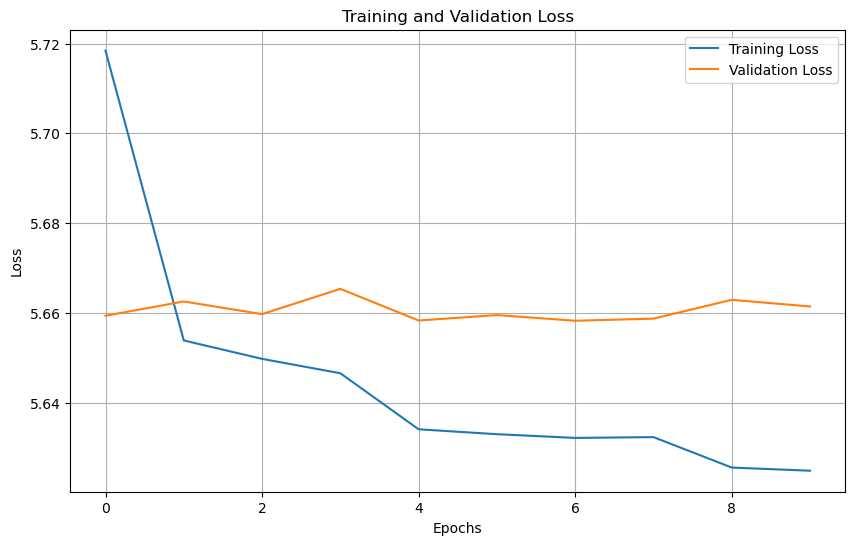

In [119]:
# Create dataset
full_dataset = LyricsMelodyDataset(train_mapping, vocab)

# Split into train and validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Initialize model
vocab_size = len(vocab)
embedding_dim = 300  # Word2Vec dimension
melody_dim = 7  # Number of melody features
hidden_dim = 256

model = LyricsMelodyGeneratorSimple(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    melody_dim=melody_dim,
    hidden_dim=hidden_dim,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix
).to(device)

# Train model
print("Training model...")
trained_model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    learning_rate=0.001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 8. Advanced Dataset for Second Approach

In [140]:
class LyricsMelodySequenceDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50, context_size=3):
        """
        Dataset for advanced lyrics generation with time-based features.

        Args:
            mappings: List of song mappings (artist, song, lyrics, midi_file)
            vocab: Dictionary mapping words to indices
            max_sequence_length: Maximum sequence length
            context_size: Number of previous words to use as context
        """
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.context_size = context_size
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        """Process all data at initialization."""
        self.data = []

        for mapping in tqdm(self.mappings, desc="Processing advanced data"):
            # Load MIDI data
            try:
                midi_data = pretty_midi.PrettyMIDI(mapping['midi_file'])
                total_duration = midi_data.get_end_time()

                # Process lyrics
                lyrics = str(mapping['lyrics']).lower()
                lines = lyrics.split('&')

                for line in lines:
                    # Clean and tokenize
                    tokens = re.findall(r'\b\w+\b', line)
                    if len(tokens) < 2:  # Skip very short lines
                        continue

                    # Add start and end tokens
                    full_tokens = ['<START>'] + tokens + ['<END>']

                    # Estimate word timings for this line
                    # For simplicity, assume each line takes (total_duration / num_lines) time
                    line_duration = total_duration / len(lines)
                    word_timings = estimate_word_durations(full_tokens, line_duration)

                    # Extract time-based features for each word
                    word_features = extract_time_based_features(midi_data, word_timings)

                    # Create training examples with context
                    for i in range(self.context_size, len(full_tokens)):
                        # Input context: previous n words
                        context_words = full_tokens[i-self.context_size:i]

                        # Target: current word
                        target_word = full_tokens[i]

                        # Get features for the target word
                        _, target_features = word_features[i]

                        # Get features for context words
                        context_features = [word_features[j][1] for j in range(i-self.context_size, i)]

                        # Add to dataset
                        self.data.append({
                            'context_words': context_words,
                            'context_features': context_features,
                            'target_word': target_word,
                            'target_features': target_features
                        })
            except Exception as e:
                print(f"Error processing {mapping['artist']} - {mapping['song']}: {e}")
                continue

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Convert words to indices
        context_indices = [self.vocab.get(w, self.vocab['<UNK>']) for w in item['context_words']]
        target_index = self.vocab.get(item['target_word'], self.vocab['<UNK>'])

        # Extract relevant features
        context_features = []
        for features in item['context_features']:
            # Create a fixed-size feature vector for each context word
            feature_vector = np.array([
                features['pitch_mean'] / 127.0,  # Normalize pitch
                features['pitch_std'] / 12.0,    # Normalize std
                features['velocity_mean'] / 127.0,  # Normalize velocity
                features['duration_mean'],       # Duration in seconds
                features['note_density'],        # Notes per second
                len(features['local_notes']),    # Number of notes
                len(features['context_before']), # Context before
                len(features['context_after'])   # Context after
            ])
            context_features.append(feature_vector)

        # Target features
        target_feature_vector = np.array([
            item['target_features']['pitch_mean'] / 127.0,
            item['target_features']['pitch_std'] / 12.0,
            item['target_features']['velocity_mean'] / 127.0,
            item['target_features']['duration_mean'],
            item['target_features']['note_density'],
            len(item['target_features']['local_notes']),
            len(item['target_features']['context_before']),
            len(item['target_features']['context_after'])
        ])

        return {
            'context_words': torch.tensor(context_indices, dtype=torch.long),
            'context_features': torch.tensor(np.array(context_features), dtype=torch.float),
            'target_word': torch.tensor(target_index, dtype=torch.long),
            'target_features': torch.tensor(target_feature_vector, dtype=torch.float)
        }

# Helper functions for the advanced dataset and model
def estimate_word_durations(tokens, total_song_duration):
    """
    Estimate the duration of each word based on letter count.

    Args:
        tokens: List of words in the lyric line
        total_song_duration: Total duration of the song in seconds

    Returns:
        List of (word, start_time, end_time) tuples
    """
    # Count total letters (as proxy for pronunciation time)
    total_letters = sum(len(word) for word in tokens)

    # Add a small fixed overhead for each word (spaces, articulation)
    word_overhead = 0.1  # seconds
    total_overhead = word_overhead * len(tokens)

    # Calculate time per letter
    if total_letters > 0:
        time_per_letter = (total_song_duration - total_overhead) / total_letters
    else:
        time_per_letter = 0

    # Calculate start and end times for each word
    word_timings = []
    current_time = 0.0

    for word in tokens:
        word_duration = (len(word) * time_per_letter) + word_overhead
        word_timings.append((word, current_time, current_time + word_duration))
        current_time += word_duration

    # Normalize to fit exactly within song duration
    if word_timings and current_time > 0:
        scale_factor = total_song_duration / current_time
        word_timings = [(word, start * scale_factor, end * scale_factor)
                        for word, start, end in word_timings]

    return word_timings

def extract_time_based_features(midi_data, word_timings):
    """
    Extract MIDI features for each word based on its estimated timing.

    Args:
        midi_data: PrettyMIDI object
        word_timings: List of (word, start_time, end_time) tuples

    Returns:
        List of (word, features) pairs
    """
    word_features = []

    for word, start_time, end_time in word_timings:
        # Initialize features for this word
        features = {
            'local_notes': [],
            'pitch_mean': 0,
            'pitch_std': 0,
            'velocity_mean': 0,
            'note_density': 0,
            'duration_mean': 0,
            'context_before': [],  # notes before this word
            'context_after': []    # notes after this word
        }

        # Context window (how far before/after to look)
        context_window = 1.0  # seconds

        # Collect notes for this word and context
        for instrument in midi_data.instruments:
            # Find notes that overlap with this word's timing
            for note in instrument.notes:
                # Note overlaps with word timing if:
                # (note starts before word ends) AND (note ends after word starts)
                note_overlaps = (note.start < end_time) and (note.end > start_time)

                # Note is in context before if it ends just before word starts
                note_before = (note.end <= start_time) and (note.end > start_time - context_window)

                # Note is in context after if it starts just after word ends
                note_after = (note.start >= end_time) and (note.start < end_time + context_window)

                if note_overlaps:
                    features['local_notes'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'duration': note.end - note.start,
                        'overlap': min(note.end, end_time) - max(note.start, start_time)
                    })

                if note_before:
                    features['context_before'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'time_to_word': start_time - note.end
                    })

                if note_after:
                    features['context_after'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'time_from_word': note.start - end_time
                    })

        # Calculate aggregate features if we have notes
        if features['local_notes']:
            features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
            features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']]) if len(features['local_notes']) > 1 else 0
            features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
            features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
            features['note_density'] = len(features['local_notes']) / (end_time - start_time) if end_time > start_time else 0

        # Add to results
        word_features.append((word, features))

    return word_features

def extract_word_time_features(midi_data, start_time, end_time):
    """Extract features for a word at a specific time window."""
    features = {
        'local_notes': [],
        'pitch_mean': 0,
        'pitch_std': 0,
        'velocity_mean': 0,
        'note_density': 0,
        'duration_mean': 0,
        'context_before': [],
        'context_after': []
    }

    context_window = 1.0  # seconds

    for instrument in midi_data.instruments:
        for note in instrument.notes:
            note_overlaps = (note.start < end_time) and (note.end > start_time)
            note_before = (note.end <= start_time) and (note.end > start_time - context_window)
            note_after = (note.start >= end_time) and (note.start < end_time + context_window)

            if note_overlaps:
                features['local_notes'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'duration': note.end - note.start,
                    'overlap': min(note.end, end_time) - max(note.start, start_time)
                })

            if note_before:
                features['context_before'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'time_to_word': start_time - note.end
                })

            if note_after:
                features['context_after'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'time_from_word': note.start - end_time
                })

    # Calculate aggregate features
    if features['local_notes']:
        features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
        features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']]) if len(features['local_notes']) > 1 else 0
        features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
        features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
        features['note_density'] = len(features['local_notes']) / (end_time - start_time) if end_time > start_time else 0

    return features

def create_feature_vector(features):
    """Create a standardized feature vector from extracted features."""
    return np.array([
        features['pitch_mean'] / 127.0 if features['local_notes'] else 0.5,
        features['pitch_std'] / 12.0 if features['local_notes'] else 0.0,
        features['velocity_mean'] / 127.0 if features['local_notes'] else 0.5,
        features['duration_mean'] if features['local_notes'] else 0.5,
        features['note_density'] if features['local_notes'] else 0.0,
        len(features['local_notes']),
        len(features['context_before']),
        len(features['context_after'])
    ])

## 9. Model Definition - Second Approach (Advanced Melody Integration)

In [141]:
## 8. Model Definition - Second Approach (Advanced Melody Integration)
class LyricsMelodyGeneratorAdvanced(nn.Module):
    def __init__(self, vocab_size, embedding_dim, feature_dim, hidden_dim,
                 context_size, num_layers, dropout, pretrained_embeddings, vocab):
        super(LyricsMelodyGeneratorAdvanced, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.context_size = context_size
        self.num_layers = num_layers
        self.vocab = vocab  # Store the vocabulary

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Feature encoder (for musical features)
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM for sequence modeling
        # Input: word embeddings + music features for each context word
        lstm_input_dim = embedding_dim + (hidden_dim // 2)
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer for context words
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        # Calculate the actual dimension after concatenation
        # final hidden state + attention output + target features
        final_dim = hidden_dim + hidden_dim + (hidden_dim // 2)

        # Output layer with the correct input dimension
        self.fc = nn.Sequential(
            nn.Linear(final_dim, hidden_dim),  # Use the actual dimension
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_words, context_features, target_features=None):
        batch_size = context_words.size(0)

        # Word embeddings for context words [batch_size, context_size, embedding_dim]
        word_embeds = self.embedding(context_words)

        # Encode music features for context words [batch_size, context_size, hidden_dim//2]
        music_embeds = self.feature_encoder(context_features)

        # Concatenate word and music embeddings
        combined_input = torch.cat([word_embeds, music_embeds], dim=2)

        # Process with LSTM
        lstm_out, (h_n, c_n) = self.lstm(combined_input)

        # Apply self-attention to get better context representation
        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Take the representation for the last word in context
        final_hidden = h_n[-1]  # [batch_size, hidden_dim]
        last_attn_output = attn_output[:, -1, :]  # [batch_size, hidden_dim]

        # Concatenate final hidden state with attention output
        final_repr = torch.cat([final_hidden, last_attn_output], dim=1)  # [batch_size, hidden_dim*2]

        # If target features provided, incorporate them
        if target_features is not None:
            target_music_embed = self.feature_encoder(target_features).squeeze(1)  # [batch_size, hidden_dim//2]
            # Use target music features in the final prediction
            final_repr = torch.cat([final_repr, target_music_embed], dim=1)  # [batch_size, hidden_dim*2 + hidden_dim//2]
        else:
            # During generation, we don't have target features, so use zeros
            dummy_features = torch.zeros(batch_size, self.hidden_dim // 2, device=context_words.device)
            final_repr = torch.cat([final_repr, dummy_features], dim=1)

        # Project to vocabulary size
        output = self.fc(final_repr)

        return output

    def generate_lyrics(self, midi_data, reverse_vocab, max_length=50,
                        start_words=None, temperature=1.0, device='cpu'):
        """
        Generate lyrics using the advanced model.

        Args:
            midi_data: PrettyMIDI object
            reverse_vocab: Dictionary mapping indices to words
            max_length: Maximum length of generated sequence
            start_words: List of words to start with (should be context_size words)
            temperature: Sampling temperature
            device: Device to run generation on

        Returns:
            List of generated words
        """
        if start_words is None:
            start_words = ['<START>'] * self.context_size
        elif len(start_words) < self.context_size:
            # Pad with START tokens if needed
            start_words = ['<START>'] * (self.context_size - len(start_words)) + start_words

        # Output sequence starts with the context words
        output_words = list(start_words)

        # Convert start words to indices
        context_indices = [self.vocab.get(w, self.vocab['<UNK>']) for w in start_words]
        context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

        # Estimate timing for the sequence
        total_duration = midi_data.get_end_time()
        # Assuming the generation will be about 50 words
        estimated_word_count = max_length
        word_duration = total_duration / estimated_word_count

        # Initial context positions (start at beginning of the song)
        current_time = 0.0
        word_timings = [(word, current_time, current_time + word_duration)
                        for word in start_words]
        current_time += word_duration * len(start_words)

        # Extract features for the context words
        context_features_list = []
        for _, start_time, end_time in word_timings:
            features = extract_word_time_features(midi_data, start_time, end_time)
            feature_vector = create_feature_vector(features)
            context_features_list.append(feature_vector)

        context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        # Generate words one by one
        for _ in range(max_length - len(start_words)):
            # No target features during generation (use None)
            with torch.no_grad():
                output = self.forward(context_tensor, context_features, None)

            # Apply temperature scaling
            output = output.div(temperature)

            # Convert to probabilities
            word_weights = output.squeeze().exp()

            # Sample from distribution
            word_idx = torch.multinomial(word_weights, 1)[0].item()

            # Convert to word
            word = reverse_vocab.get(word_idx, '<UNK>')

            # End sequence if end token or period
            if word == '<END>' or word == '.':
                break

            # Add to output
            output_words.append(word)

            # Update context for next iteration
            context_indices = context_indices[1:] + [word_idx]
            context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

            # Update word timing and extract features
            next_timing = (word, current_time, current_time + word_duration)
            current_time += word_duration

            next_features = extract_word_time_features(midi_data, next_timing[1], next_timing[2])
            next_feature_vector = create_feature_vector(next_features)

            # Update context features
            context_features_list = context_features_list[1:] + [next_feature_vector]
            context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        return output_words

## 10. Train Advanced Model

In [142]:
def train_advanced_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the advanced model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            context_words = batch['context_words'].to(device)
            context_features = batch['context_features'].to(device)
            target_word = batch['target_word'].to(device)
            target_features = batch['target_features'].to(device)

            outputs = model(context_words, context_features, target_features)
            loss = criterion(outputs, target_word)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                context_words = batch['context_words'].to(device)
                context_features = batch['context_features'].to(device)
                target_word = batch['target_word'].to(device)
                target_features = batch['target_features'].to(device)

                outputs = model(context_words, context_features, target_features)
                loss = criterion(outputs, target_word)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

In [ ]:
# Create the advanced dataset
print("Creating advanced dataset...")
advanced_dataset = LyricsMelodySequenceDataset(train_mapping, vocab, context_size=3)

# Split into train and validation
adv_train_size = int(0.8 * len(advanced_dataset))
adv_val_size = len(advanced_dataset) - adv_train_size
adv_train_dataset, adv_val_dataset = torch.utils.data.random_split(
    advanced_dataset, [adv_train_size, adv_val_size])

# Create data loaders
adv_train_loader = DataLoader(adv_train_dataset, batch_size=64, shuffle=True)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=64)

print(f"Advanced train dataset size: {len(adv_train_dataset)}")
print(f"Advanced validation dataset size: {len(adv_val_dataset)}")

# Initialize the advanced model
feature_dim = 8  # Our fixed feature vector size
context_size = 3 # Number of context words

advanced_model = LyricsMelodyGeneratorAdvanced(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    feature_dim=feature_dim,
    hidden_dim=hidden_dim,
    context_size=context_size,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix,
    vocab=vocab  # Pass the vocabulary
).to(device)

# Train the advanced model
print("Training advanced model...")
trained_advanced_model, adv_train_losses, adv_val_losses = train_advanced_model(
    model=advanced_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    epochs=10,
    learning_rate=0.001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(adv_train_losses, label='Training Loss')
plt.plot(adv_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Advanced Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Creating advanced dataset...


Processing advanced data:   0%|          | 1/594 [00:00<07:29,  1.32it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing advanced data:   0%|          | 2/594 [00:01<09:07,  1.08it/s]

## 11. Generating Lyrics for Test Set

In [138]:
def generate_lyrics_for_test(model, melody_data, reverse_vocab, start_words=['love', 'night', 'dream'],
                             max_length=50, temperature=0.8, device='cpu'):
    """Generate lyrics for test data with different starting words."""
    generated_lyrics = {}

    for start_word in start_words:
        if start_word not in vocab:
            print(f"Warning: '{start_word}' not in vocabulary. Using '<START>' instead.")
            start_word = '<START>'

        lyrics = model.generate_lyrics(
            melody_data, reverse_vocab, max_length=max_length,
            start_word=start_word, temperature=temperature, device=device
        )

        # Format lyrics for display
        formatted_lyrics = ' '.join([w for w in lyrics if w not in ['<START>', '<END>']])
        generated_lyrics[start_word] = formatted_lyrics

    return generated_lyrics

def generate_lyrics_with_advanced_model(model, midi_data, reverse_vocab,
                                        start_words=['love', 'night', 'dream'],
                                        max_length=50, temperature=0.8, device='cpu'):
    """Generate lyrics using the advanced model."""
    context_size = model.context_size
    generated_lyrics = {}

    for start_word in start_words:
        # Create context with START tokens and the start word
        if start_word not in vocab:
            print(f"Warning: '{start_word}' not in vocabulary. Using '<START>' instead.")
            start_word = '<START>'

        context = ['<START>'] * (context_size - 1) + [start_word]

        # Generate lyrics
        lyrics = model.generate_lyrics(
            midi_data=midi_data,
            reverse_vocab=reverse_vocab,
            max_length=max_length,
            start_words=context,
            temperature=temperature,
            device=device
        )

        # Format lyrics for display
        formatted_lyrics = ' '.join([w for w in lyrics if w not in ['<START>', '<END>']])
        generated_lyrics[start_word] = formatted_lyrics

    return generated_lyrics




### Test Set Evaluation - Simple Model

In [136]:
# Check if test mappings are available
if 'test_mapping' in locals() and len(test_mapping) > 0 and 'trained_model' in locals():
    # Set start words for generation
    start_words = ['love', 'night', 'dream']

    # Results dictionary
    all_test_results_simple = {}

    for test_item in test_mapping:
        print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

        # Extract melody features
        midi_features = load_midi_features(test_item['midi_file'])
        if midi_features is None:
            print(f"Error: Could not extract features from {test_item['midi_file']}")
            continue

        # Prepare melody features for simple model
        melody_feats = np.array([
            midi_features.get('avg_pitch', 0),
            midi_features.get('pitch_std', 0),
            midi_features.get('pitch_range', 0),
            midi_features.get('avg_duration', 0),
            midi_features.get('avg_velocity', 0),
            midi_features.get('note_density', 0),
            midi_features.get('tempo', 120) / 120.0,
        ])

        # Generate lyrics with simple model
        test_results = generate_lyrics_for_test(
            model=trained_model,
            melody_data=melody_feats,
            reverse_vocab={v: k for k, v in vocab.items()},
            start_words=start_words,
            max_length=50,
            temperature=0.8,
            device=device
        )

        all_test_results_simple[f"{test_item['artist']} - {test_item['song']}"] = test_results

        # Print generated lyrics
        for start_word, lyrics in test_results.items():
            print(f"\nStarting with '{start_word}':")
            print(lyrics)
else:
    print("No test mappings available or model not trained.")


Generating lyrics for: the_bangles - eternal_flame

Starting with 'love':
love to

Starting with 'night':
night there me

Starting with 'dream':
dream

Generating lyrics for: billy_joel - honesty

Starting with 'love':
love get it i i

Starting with 'night':
night

Starting with 'dream':
dream in to

Generating lyrics for: cardigans - lovefool

Starting with 'love':
love i

Starting with 'night':
night

Starting with 'dream':
dream

Generating lyrics for: aqua - barbie_girl

Starting with 'love':
love that i on

Starting with 'night':
night

Starting with 'dream':
dream

Generating lyrics for: blink_182 - all_the_small_things

Starting with 'love':
love i

Starting with 'night':
night the the

Starting with 'dream':
dream


### Test Set Evaluation - Advanced Model

In [139]:
# Check if test mappings are available
if 'test_mapping' in locals() and len(test_mapping) > 0 and 'trained_advanced_model' in locals():
    # Results dictionary
    all_test_results_advanced = {}

    for test_item in test_mapping[:3]:  # Limit to first 3 for demonstration
        print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

        # Load MIDI data
        try:
            midi_data = pretty_midi.PrettyMIDI(test_item['midi_file'])

            # Generate lyrics with advanced model
            test_results = generate_lyrics_with_advanced_model(
                model=trained_advanced_model,
                midi_data=midi_data,
                reverse_vocab={v: k for k, v in vocab.items()},
                start_words=['love', 'night', 'dream'],
                max_length=50,
                temperature=0.8,
                device=device
            )

            all_test_results_advanced[f"{test_item['artist']} - {test_item['song']}"] = test_results

            # Print generated lyrics
            for start_word, lyrics in test_results.items():
                print(f"\nStarting with '{start_word}':")
                print(lyrics)

        except Exception as e:
            print(f"Error generating lyrics for {test_item['artist']} - {test_item['song']}: {e}")
            continue
else:
    print("No test mappings available or advanced model not trained.")


Generating lyrics for: the_bangles - eternal_flame
Error generating lyrics for the_bangles - eternal_flame: 'LyricsMelodyGeneratorAdvanced' object has no attribute 'vocab'

Generating lyrics for: billy_joel - honesty
Error generating lyrics for billy_joel - honesty: 'LyricsMelodyGeneratorAdvanced' object has no attribute 'vocab'

Generating lyrics for: cardigans - lovefool
Error generating lyrics for cardigans - lovefool: 'LyricsMelodyGeneratorAdvanced' object has no attribute 'vocab'


## 12. Comparative Analysis

In [104]:
if 'all_test_results_simple' in locals() and 'all_test_results_advanced' in locals():
    print("Comparative Analysis of Generated Lyrics\n")


    # Calculate average length of generated lyrics
    def avg_length(lyrics_dict):
        total_length = 0
        count = 0
        for song, results in lyrics_dict.items():
            for start_word, lyrics in results.items():
                words = lyrics.split()
                total_length += len(words)
                count += 1
        return total_length / count if count > 0 else 0


    simple_avg_length = avg_length(all_test_results_simple)
    advanced_avg_length = avg_length(all_test_results_advanced)

    print(f"Simple Model - Average Length: {simple_avg_length:.2f} words")
    print(f"Advanced Model - Average Length: {advanced_avg_length:.2f} words")

    # Display a few sample comparisons
    print("\nSample Comparisons:")

    common_songs = set(all_test_results_simple.keys()) & set(all_test_results_advanced.keys())
    for song in list(common_songs)[:2]:  # Show first 2 common songs
        print(f"\n{song}")

        for start_word in ['love', 'night', 'dream']:
            print(f"\nStarting with '{start_word}':")

            if start_word in all_test_results_simple[song]:
                print(f"Simple Model: {all_test_results_simple[song][start_word]}")

            if start_word in all_test_results_advanced[song]:
                print(f"Advanced Model: {all_test_results_advanced[song][start_word]}")
else:
    print("Results from both models not available for comparison.")

## 13. Save Models and Results
# Save models
if 'trained_model' in locals():
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'simple_lyrics_model.pth')
    print("Simple model saved!")

if 'trained_advanced_model' in locals():
    torch.save({
        'model_state_dict': trained_advanced_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'advanced_lyrics_model.pth')
    print("Advanced model saved!")

# Save generated lyrics
if 'all_test_results_simple' in locals() and 'all_test_results_advanced' in locals():
    # Save as text file
    with open('generated_lyrics_results.txt', 'w') as f:
        f.write("==== SIMPLE MODEL RESULTS ====\n\n")
        for song, results in all_test_results_simple.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

        f.write("\n\n==== ADVANCED MODEL RESULTS ====\n\n")
        for song, results in all_test_results_advanced.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

    print("Generated lyrics results saved to 'generated_lyrics_results.txt'")

Comparative Analysis of Generated Lyrics

Simple Model - Average Length: 1.80 words
Advanced Model - Average Length: 2.00 words

Sample Comparisons:

blink_182 - all_the_small_things

Starting with 'love':
Simple Model: love
Advanced Model: love

Starting with 'night':
Simple Model: night you
Advanced Model: night

Starting with 'dream':
Simple Model: dream in the
Advanced Model: dream i don t have to know the you sleep

cardigans - lovefool

Starting with 'love':
Simple Model: love
Advanced Model: love

Starting with 'night':
Simple Model: night t
Advanced Model: night

Starting with 'dream':
Simple Model: dream till
Advanced Model: dream


## 13. Save Models and Results

In [ ]:
# Save models
if 'trained_model' in locals():
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'simple_lyrics_model.pth')
    print("Simple model saved!")

if 'trained_advanced_model' in locals():
    torch.save({
        'model_state_dict': trained_advanced_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'advanced_lyrics_model.pth')
    print("Advanced model saved!")

# Save generated lyrics
if 'all_test_results_simple' in locals() and 'all_test_results_advanced' in locals():
    # Save as text file
    with open('generated_lyrics_results.txt', 'w') as f:
        f.write("==== SIMPLE MODEL RESULTS ====\n\n")
        for song, results in all_test_results_simple.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

        f.write("\n\n==== ADVANCED MODEL RESULTS ====\n\n")
        for song, results in all_test_results_advanced.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

    print("Generated lyrics results saved to 'generated_lyrics_results.txt'")